# Computational Thermofluid Dynamics - Chapter 5

Technical University of Munich, Professur für Thermofluiddynamik - Pr. Polifke

Created: 04/2024 | J. Yao, N. Garcia, G. Varillon

Revised: 10/2025 | A. Keles

==============================================================================================

# FVM Solver

In this stage, you will implement a **2D steady-state heat conduction solver** using the Finite Volume Method (FVM) with all boundary condition types.

The **form function** defining the geometry is already provided — do **not** modify it.  
Your task starts from the **mesh generation** using `setupMesh()`.  
First, **visualize the mesh** to verify that the geometry and node layout are correct.

Next, complete the helper class and functions:
- `Coordinate2D` class  
- `calculate_area`, `dx`, `dy`, `dist`, and `index` functions  
Refer to the provided Skriptum for the necessary geometric and differential relations.

In the **main solver class**:
1. Initialize all required parameters similarly to the Finite Difference (FD) exercise.  
2. In the `set_stencil()` method, identify whether each node belongs to the interior, boundary, or corner region, and call the respective `build_*()` function.  
   - `build_inner()` and `build_north()` are already implemented as examples.  
   - You must implement the remaining boundary and corner functions yourself.

Inside the `solve()` method:
- Loop through each node in the computational domain.  
- Call `set_stencil()` for each node to assemble the global coefficient matrix **A** and source vector **B**.  
- After assembly, solve the linear system and reshape the resulting temperature field into 2D form.

Finally, visualize the computed temperature field using the provided plotting routine.  
Note that you are solving only the **upper half** of the geometry.  
Reconstruct the full domain for plotting using `np.flipud()` and `np.vstack()` to mirror the field across the symmetry line.


In [127]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import time

## Form function to change the shape of domain
![Domain](domain.png)
see Figure 3.4


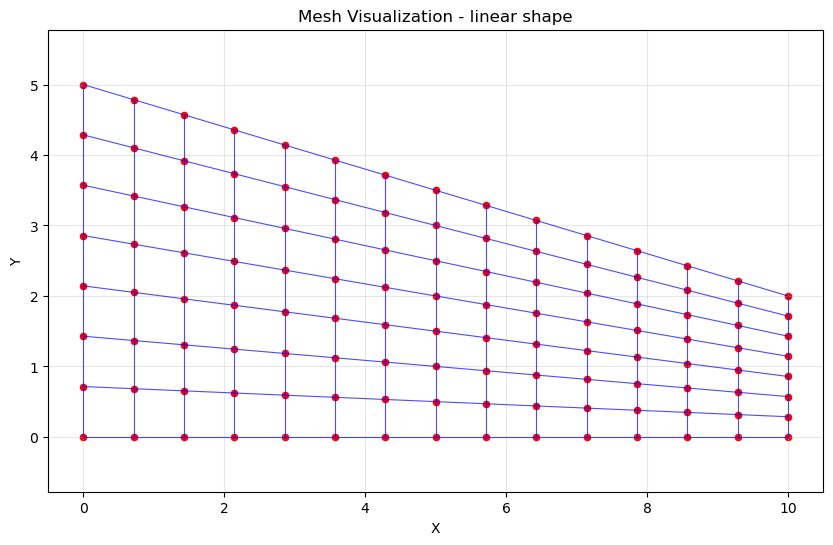

In [128]:
def formfunction(x, shape):
    """
    Defines the shape of north boundary
    takes an array and shape
    returns an array
    """
    h1 = x[-1]           # west boundary height
    h2 = x[-1] / 10 * 4  # east boundary height
    l  = x[-1]           # domain length
    if shape == 'linear':
        m = (h2 - h1) / (2 * l)
        b = h1 / 2
        return m * x + b
    
    elif shape == 'rectangular':
        return l * np.ones((x.size, 1))
        
    elif shape == 'quadratic':
        k = 2 * l**2 / (h1 - h2)
        return (x - l)**2 / k + h2 / 2 
    
    elif shape == 'crazy':
        return h1/2 + (h2/2 - h1/2) * x / l + 0.25*(-h1 + h2/2) * np.sin(np.pi*x/l)**2
    
    else:
        raise ValueError('Unknown shape: %s' % shape)

def setUpMesh(nodes_x, nodes_y, length, formfunction, shape):
    # 1D x coordinates
    X = np.linspace(0, length, nodes_x)

    # Compute half-height profile along X
    y_profile = formfunction(X, shape).flatten() 
    
    # Initialize Y mesh
    Y = np.zeros((nodes_y, nodes_x))
    
    for j in range(nodes_x):
        # Local half height at this x-position
        local_h = y_profile[j]
        
        # Linear distribution from local height to 0 along Y-direction
        Y[:, j] = np.linspace(local_h, 0, nodes_y)
    
    # Repeat X along rows to create 2D mesh
    X = np.array([X[:] for i in range(nodes_y)])
    
    return X, Y
# Parameters for mesh generation
nodes_x = 15
nodes_y = 8
length = 10

# Change this variable to plot different shapes
selected_shape = 'linear'  # Options: 'linear', 'rectangular', 'quadratic', 'crazy'

# Generate and visualize mesh for the selected shape
X, Y = setUpMesh(nodes_x, nodes_y, length, formfunction, selected_shape)

plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'b-', linewidth=0.8, alpha=0.7)
plt.plot(X.T, Y.T, 'b-', linewidth=0.8, alpha=0.7)
plt.scatter(X, Y, c='red', s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Mesh Visualization - {selected_shape} shape')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [129]:
class Coordinate2D():
    def __init__(self, x, y):
        self.x = x
        self.y = y

def calculate_area(ul, bl, br, ur):
    # calculate the area of the cell
    # ul (upper left), bl (bottom left), br (bottom right), ur (upper right) are the coordinates of the four vertices of the cell
    # apply Gaussian trapezoidal formula to calculate the areas

    x = [ul.x, bl.x, br.x, ur.x]
    y = [ul.y, bl.y, br.y, ur.y]
    
    area = 0.5 * abs(
        x[0]*y[1] + x[1]*y[2] + x[2]*y[3] + x[3]*y[0] - y[0]*x[1] - y[1]*x[2] - y[2]*x[3] - y[3]*x[0]
        )
    return area

def dy(a, b):
    # Calculate distance between 'a' and 'b' along the y axis
    return (b.y - a.y)
    
def dx(a, b):
    # Calculate distance between 'a' and 'b' along the x axis
    return (b.x - a.x)
    
def dist(a, b):
    # Calculate the euclidean distance between 'a' and 'b'
    return np.sqrt((b.x - a.x)**2 + (b.y - a.y)**2)

In [ ]:
class SteadyHeat2D_FVM():
    def __init__(self, X, Y, boundary=[], TD=[], q=0.0, alpha=0.0, Tinf=0.0):
        # i, j is the index of the cell
        # X, Y is the mesh
        # boundary is the boundary condition: "R", "D", "N"
        # TD is the Dirichlet Temperature
        # q is the heat flux
        # alpha is the heat transfer coefficient
        # Tinf is the temperature of the surrounding

        self.X = X
        self.Y = Y
        self.boundary = boundary
        self.TD = TD
        self.q = q
        self.alpha = alpha
        self.Tinf = Tinf

        # n is the number of points in the first direction
        # m is the number of points in the second direction
        self.m, self.n = X.shape

        total_nodes = self.m * self.n
        self.A = sp.lil_matrix((total_nodes, total_nodes))
        self.B = np.zeros(total_nodes)

    def index(self, i, j):
        # Return the index in the computational vector
       return i * self.n + j
       
    def stable_area(self, *args):
         # Stable area calculation wrapper
         area = calculate_area(*args)
         return area if area > 1e-12 else 1e-12

    def set_stencil(self, i, j):
        # Based on 'i','j' decide if the node is inner or boundary (which boundary?)
        # Check for corner nodes first
        if i == 0 and j == 0:  # North-West corner
            return self.build_NW(i, j)
        elif i == 0 and j == self.n-1:  # North-East corner  
            return self.build_NE(i, j)
        elif i == self.m-1 and j == 0:  # South-West corner
            return self.build_SW(i, j)
        elif i == self.m-1 and j == self.n-1:  # South-East corner
            return self.build_SE(i, j)
        # Check for boundary nodes
        elif i == 0:  # North boundary
            return self.build_north(i, j)
        elif i == self.m-1:  # South boundary
            return self.build_south(i, j)
        elif j == 0:  # West boundary
            return self.build_west(i, j)
        elif j == self.n-1:  # East boundary
            return self.build_east(i, j)
        else:  # Inner node
            return self.build_inner(i, j)

    def build_inner(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        # % Nomenclature:
        # %
        # %    NW(i-1,j-1)   Nw -  N(i-1,j) -  Ne     NE(i-1,j+1)
        # %
        # %                 |                 |
        # %
        # %       nW - - - - nw ------ n ------ ne - - - nE
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %   W(i, j-1) - - w - - P (i,j) - - e - -  E (i,j+1)
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %      sW - - - - sw ------ s ------ se - - - sE
        # %
        # %                 |                 |
        # %
        # %   SW(i+1,j-1)   Sw  -  S(i+1,j)  - Se      SE(i+1,j+1)
        # %
        # % Indexing of stencil: 

        # %    D_4 - D_1 - D2
        # %     |     |     | 
        # %    D_3 - D_0 - D3
        # %     |     |     | 
        # %    D_2 -  D1 - D4

        # principle node coordinate
        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        # auxiliary node coordinate
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
        sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)
        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)
        
        # calculate the area of the cell
        S_P = calculate_area(ne, se, sw, nw)
        S_n = calculate_area(Ne, e, w, Nw)
        S_s = calculate_area(e, Se, Sw, w)
        S_w = calculate_area(n, s, sW, nW)
        S_e = calculate_area(nE, sE, s, n)

        D3 = ((dx(se, ne) * (dx(nE, n)/4 + dx(s, sE)/4 + dx(sE, nE))) / S_e + 
             (dy(se, ne) * (dy(nE, n)/4 + dy(s, sE)/4 + dy(sE, nE))) / S_e + 
             (dx(e, Ne) * dx(ne, nw)) / (4*S_n) + (dx(Se,e) * dx(sw,se)) / (4*S_s) + 
             (dy(e, Ne) * dy(ne, nw)) / (4*S_n) + (dy(Se,e) * dy(sw,se)) / (4*S_s)) / S_P
        D_3 = ((dx(nw, sw) * (dx(n, nW) / 4 + dx(sW, s) / 4 + dx(nW, sW))) / S_w +
              (dy(nw, sw) * (dy(n, nW) / 4 + dy(sW, s) / 4 + dy(nW, sW))) / S_w +
              (dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
              (dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
              (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
              (dy(w, Sw) * dy(sw, se)) / (4 * S_s)) / S_P
        D1 = ((dx(sw, se) * (dx(Se, e) / 4 + dx(w, Sw) / 4 + dx(Sw, Se))) / S_s +
            (dy(sw, se) * (dy(Se, e) / 4 + dy(w, Sw) / 4 + dy(Sw, Se))) / S_s +
            (dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P
        # North
        D_1 = ((dx(ne, nw) * (dx(e, Ne) / 4 + dx(Nw, w) / 4 + dx(Ne, Nw))) / S_n +
            (dy(ne, nw) * (dy(e, Ne) / 4 + dy(Nw, w) / 4 + dy(Ne, Nw))) / S_n +
            (dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NW
        D_4 = ((dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NE
        D2 = ((dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(e, Ne) * dx(ne, nw)) / (4 * S_n) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(e, Ne) * dy(ne, nw)) / (4 * S_n)) / S_P

        # SW
        D_2 = ((dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(w, Sw) * dy(sw, se)) / (4 * S_s) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P

        # SE
        D4 = ((dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(Se, e) * dx(sw, se)) / (4 * S_s) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(Se, e) * dy(sw, se)) / (4 * S_s)) / S_P

        # Center (P)
        D0 = ((dx(se, ne) * (dx(n, s) + dx(nE, n) / 4 + dx(s, sE) / 4)) / S_e +
            (dx(ne, nw) * (dx(w, e) + dx(e, Ne) / 4 + dx(Nw, w) / 4)) / S_n +
            (dx(sw, se) * (dx(e, w) + dx(Se, e) / 4 + dx(w, Sw) / 4)) / S_s +
            (dx(nw, sw) * (dx(s, n) + dx(n, nW) / 4 + dx(sW, s) / 4)) / S_w +
            (dy(se, ne) * (dy(n, s) + dy(nE, n) / 4 + dy(s, sE) / 4)) / S_e +
            (dy(ne, nw) * (dy(w, e) + dy(e, Ne) / 4 + dy(Nw, w) / 4)) / S_n +
            (dy(sw, se) * (dy(e, w) + dy(Se, e) / 4 + dy(w, Sw) / 4)) / S_s +
            (dy(nw, sw) * (dy(s, n) + dy(n, nW) / 4 + dy(sW, s) / 4)) / S_w) / S_P
        
        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j-1)] = D_3
        stencil[self.index(i, j+1)] = D3
        stencil[self.index(i-1, j-1)] = D_4
        stencil[self.index(i-1, j+1)] = D2
        stencil[self.index(i+1, j-1)] = D_2
        stencil[self.index(i+1, j+1)] = D4
        
        return stencil,b
        
    
    def build_north(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b = self.TD[0]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

            # auxiliary node coordinate
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
            sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)

            # calculate the area of the cell
            S_ss = calculate_area(e, se, sw, w)
            S_s = calculate_area(e, Se, Sw, w)
            S_ssw = calculate_area(P, s, sW, W)
            S_sse = calculate_area(E, sE, s, P)

            # East
            D3 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_sse) / S_ss

            # West
            D_3 = (dy(w, sw) * (3 * dy(W, sW) / 4 + dy(sW, s) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (3 * dx(W, sW) / 4 + dx(sW, s) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # South
            D1 = (dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Sw, Se) + dy(Se, e) / 4) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Sw, Se) + dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(P, s) / 4 + dy(s, sE) / 4) / S_sse +
                dx(se, e) * (dx(P, s) / 4 + dx(s, sE) / 4) / S_sse) / S_ss

            # SW
            D_2 = (dy(w, sw) * (dy(W, sW) / 4 + dy(sW, s) / 4) / S_ssw +
                dx(w, sw) * (dx(W, sW) / 4 + dx(sW, s) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # SE
            D4 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_sse) / S_ss
            
            coefficient = 0.0
            if self.boundary[0] == 'N':
                coefficient = 0.0
                b = self.q * dist(e, w) / S_ss
            elif self.boundary[0] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(e, w) / S_ss
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            D0 = (coefficient * dist(e, w) +
                dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(s, P) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(s, P) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Se, e) / 4 + dy(e, w)) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Se, e) / 4 + dx(e, w)) / S_s +
                dy(se, e) * (3 * dy(P, s) / 4 + dy(s, sE) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (3 * dx(P, s) / 4 + dx(s, sE) / 4 + dx(E, P) / 2) / S_sse) / S_ss
            
            stencil[self.index(i, j)] = D0
            stencil[self.index(i+1, j)] = D1
            stencil[self.index(i, j-1)] = D_3
            stencil[self.index(i, j+1)] = D3
            stencil[self.index(i+1, j-1)] = D_2
            stencil[self.index(i+1, j+1)] = D4

        return stencil,b
    
    def build_south(self, i, j):
        """Build stencil for south boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

        n  = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        w  = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e  = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)

        S_nn  = self.stable_area(e, ne, nw, w)
        S_n   = self.stable_area(e, Ne, Nw, w)
        S_nnw = self.stable_area(P, n, nW, W)
        S_nne = self.stable_area(E, nE, n, P)

        D3 = (dy(nw, ne) * dy(Ne, e) / 4 / S_n + dx(nw, ne) * dx(Ne, e) / 4 / S_n +
            dy(ne, e) * (dy(n, nE)/4 + 3*dy(nE, E)/4 + dy(E, P)/2) / S_nne +
            dx(ne, e) * (dx(n, nE)/4 + 3*dx(nE, E)/4 + dx(E, P)/2) / S_nne) / S_nn

        D_3 = (dy(w, nw) * (3*dy(W, nW)/4 + dy(nW, n)/4 + dy(P, W)/2) / S_nnw +
            dx(w, nw) * (3*dx(W, nW)/4 + dx(nW, n)/4 + dx(P, W)/2) / S_nnw +
            dy(nw, ne) * dy(w, Nw)/4 / S_n + dx(nw, ne) * dx(w, Nw)/4 / S_n) / S_nn

        D_1 = (dy(w, nw) * (dy(nW, n)/4 + dy(n, P)/4) / S_nnw +
            dx(w, nw) * (dx(nW, n)/4 + dx(n, P)/4) / S_nnw +
            dy(nw, ne) * (dy(w, Nw)/4 + dy(Nw, Ne) + dy(Ne, e)/4) / S_n +
            dx(nw, ne) * (dx(w, Nw)/4 + dx(Nw, Ne) + dx(Ne, e)/4) / S_n +
            dy(ne, e) * (dy(P, n)/4 + dy(n, nE)/4) / S_nne +
            dx(ne, e) * (dx(P, n)/4 + dx(n, nE)/4) / S_nne) / S_nn

        D4 = (dy(w, nw) * (dy(W, nW)/4 + dy(nW, n)/4) / S_nnw +
            dx(w, nw) * (dx(W, nW)/4 + dx(nW, n)/4) / S_nnw +
            dy(nw, ne) * dy(w, Nw)/4 / S_n + dx(nw, ne) * dx(w, Nw)/4 / S_n) / S_nn

        D2 = (dy(nw, ne) * dy(Ne, e)/4 / S_n + dx(nw, ne) * dx(Ne, e)/4 / S_n +
            dy(ne, e) * (dy(n, nE)/4 + dy(nE, E)/4) / S_nne +
            dx(ne, e) * (dx(n, nE)/4 + dx(nE, E)/4) / S_nne) / S_nn

        if self.boundary[1] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(e, w) / S_nn  
        elif self.boundary[1] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(e, w) / S_nn 
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[1]}')

        D0 = (coefficient * dist(e, w) +
            dy(w, nw) * (dy(nW, n)/4 + 3*dy(n, P)/4 + dy(P, W)/2) / S_nnw +
            dx(w, nw) * (dx(nW, n)/4 + 3*dx(n, P)/4 + dx(P, W)/2) / S_nnw +
            dy(nw, ne) * (dy(w, Nw)/4 + dy(Ne, e)/4 + dy(e, w)) / S_n +
            dx(nw, ne) * (dx(w, Nw)/4 + dx(Ne, e)/4 + dx(e, w)) / S_n +
            dy(ne, e) * (3*dy(P, n)/4 + dy(n, nE)/4 + dy(E, P)/2) / S_nne +
            dx(ne, e) * (3*dx(P, n)/4 + dx(n, nE)/4 + dx(E, P)/2) / S_nne) / S_nn

        stencil[self.index(i, j)]     = D0
        stencil[self.index(i-1, j)]   = D_1
        stencil[self.index(i, j-1)]   = D_3
        stencil[self.index(i, j+1)]   = D3
        stencil[self.index(i-1, j-1)] = D4
        stencil[self.index(i-1, j+1)] = D2

        return stencil, b[0]
    
    def build_west(self, i, j):
        """Build stencil for west boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0]  

        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)

        S_ww = self.stable_area(s, n, ne, se)
        S_w = self.stable_area(s, n, nE, sE)
        S_wws = self.stable_area(S, P, e, Se)
        S_wwn = self.stable_area(P, N, Ne, e)

        D_1 = -(dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_wwn) / S_ww

        D1 = -(dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(s, sE) / 4) / S_w +
                dy(se, s) * (dy(sE, S) / 4 + 3 * dy(Se, S) / 4 + dy(S, P) / 2) / S_wws +
                dx(se, s) * (dx(sE, S) / 4 + 3 * dx(Se, S) / 4 + dx(S, P) / 2) / S_wws) / S_ww

        D3 = -(dy(s, se) * (dy(Se, e) / 4 + dy(e, P) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(e, P) / 4) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(sE, nE) + dy(nE, n) / 4) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(sE, nE) + dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(P, e) / 4 + dy(e, Ne) / 4) / S_wwn +
                dx(ne, n) * (dx(P, e) / 4 + dx(e, Ne) / 4) / S_wwn) / S_ww

        D2 = -(dy(ne, n) * (dy(e, Ne) / 4 + dy(Ne, N) / 4) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + dx(Ne, N) / 4) / S_wwn +
                dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w) / S_ww

        D4 = -(dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(Se, s) / 4) / S_w +
                dy(s, se) * (dy(Se, e) / 4 + dy(Se, S) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(Se, S) / 4) / S_wws) / S_ww
        
        if self.boundary[2] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(n, s) / S_ww  
        elif self.boundary[2] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(n, s) / S_ww  
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[2]}')
        
        D0 = (coefficient * dist(ne, se) +
                dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(nE, n) / 4 + dy(n, s)) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(nE, n) / 4 + dx(n, s)) / S_w +
                dy(ne, n) * (3 * dy(P, e) / 4 + dy(e, Ne) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (3 * dx(P, e) / 4 + dx(e, Ne) / 4 + dx(N, P) / 2) / S_wwn) / S_ww
        
        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j+1)] = D3
        stencil[self.index(i-1, j+1)] = D2
        stencil[self.index(i+1, j+1)] = D4

        return stencil, b[0]  
    
    def build_east(self, i, j):
        """Build stencil for east boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0]  

        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)

        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)

        nw = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)
        sw = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

        S_ee = self.stable_area(s, sw, nw, n)
        S_e = self.stable_area(n, s, sW, nW)
        S_ees = self.stable_area(P, S, Sw, w)
        S_een = self.stable_area(N, P, w, Nw)

        D_1 = (dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_een) / S_ee
            
        D1 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(Sw, S) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(Sw, S) / 4 + dx(S, P) / 2) / S_ees) / S_ee

        D_3 = (dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(nW, sW) + dy(n, nW) / 4) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(nW, sW) + dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_een) / S_ee

        D_4 = (dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_een +
                dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e) / S_ee

        D_2 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_ees +
                dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_ees) / S_ee
        
        if self.boundary[3] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(n, s) / S_ee  
        elif self.boundary[3] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(n, s) / S_ee  
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[3]}')
        
        D0 = (coefficient * dist(nw, sw) +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(P, w) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(P, w) / 4 + dx(S, P) / 2) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(n, nW) / 4 + dy(s, n)) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(n, nW) / 4 + dx(s, n)) / S_e +
                dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_een) / S_ee

        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j-1)] = D_3
        stencil[self.index(i-1, j-1)] = D_4
        stencil[self.index(i+1, j-1)] = D_2

        return stencil, b[0] 
    
    def build_NW(self, i, j):
        """Build stencil for North-West corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[0]  
            return stencil, b[0] 
        
        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        S  = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        s   = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        e   = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
        Se  = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        sE  = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
        se  = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)

        S_nw  = self.stable_area(P, s, se, e)       
        S_nws = self.stable_area(P, S, Se, e)
        S_nwe = self.stable_area(P, s, sE, E)

        coeff_N = coeff_W = 0.0
        b[0] = 0.0  

        if self.boundary[0] == 'N':
            b[0] += self.q * dist(e, P) / S_nw  
        elif self.boundary[0] == 'R':
            coeff_N = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(e, P) / S_nw  

        if self.boundary[2] == 'N':
            b[0] += self.q * dist(P, s) / S_nw 
        elif self.boundary[2] == 'R':
            coeff_W = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, s) / S_nw 

        D0 = (
            coeff_N * dist(e, P) +
            coeff_W * dist(s, P) +
            dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_nws +
            dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_nws +
            dy(se, e) * (3 * dy(s, P)/4 + dy(sE,s)/4 + dy(P, E)/2) / S_nwe +
            dx(se, e) * (3 * dx(s, P)/4 + dx(sE,s)/4 + dx(P, E)/2) / S_nwe
        ) / S_nw

        D1 = (
            dy(s, se) * (dy(e, Se) / 4 + 3 * dy(Se, S) / 4 + dy(S, P) / 2) / S_nws +
            dx(s, se) * (dx(e, Se) / 4 + 3 * dx(Se, S) / 4 + dx(S, P) / 2) / S_nws +
            dy(se, e) * (dy(s, sE)/4 + dy(sE, E)/4) / S_nwe +
            dx(se, e) * (dx(s, sE)/4 + dx(sE, E)/4) / S_nwe
        ) / S_nw

        D3 = ( 
            dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_nwe +
            dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_nwe +
            dy(s, se) * (dy(e, Se)) /4 / S_nws +
            dx(s, se) * (dx(e, Se)) /4 / S_nws 
        ) / S_nw
        
        D4 = (
            dy(s, se) * (dy(Se, S) / 4 + dy(e, Se) / 4) / S_nws +
            dx(s, se) * (dx(Se, S) / 4 + dx(e, Se) / 4) / S_nws +
            dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_nwe +
            dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_nwe
        ) / S_nw

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i+1, j)]     = D1
        stencil[self.index(i, j+1)]     = D3
        stencil[self.index(i+1, j+1)]   = D4

        return stencil, b[0]  
    
    def build_NE(self, i, j):
        """Build stencil for North-East corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[0]  
            return stencil, b[0]  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        S  = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])

        s   = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w   = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        Sw  = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        sW  = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sw  = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

        S_ne  = self.stable_area(w, sw, s, P)
        S_nes = self.stable_area(P, w, Sw, S)
        S_new = self.stable_area(P, W, sW, s)

        coeff_N = coeff_E = 0.0
        b[0] = 0.0  

        if self.boundary[0] == 'N':
            b[0] += self.q * dist(w, P) / S_ne  
        elif self.boundary[0] == 'R':
            coeff_N = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(w, P) / S_ne  
        if self.boundary[3] == 'N':
            b[0] += self.q * dist(P, s) / S_ne 
        elif self.boundary[3] == 'R':
            coeff_E = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, s) / S_ne  
        D0 = (
            coeff_N * dist(w, P) +
            coeff_E * dist(P, s) +
            dy(sw, s) * (3 * dy(P, w) / 4 + dy(w, Sw) / 4 +  dy(S, P) / 2) / S_nes +
            dx(sw, s) * (3 * dx(P, w) / 4 + dx(w, Sw) / 4  + dx(S, P) / 2) / S_nes +
            dy(w, sw) * (3 * dy(s, P) / 4 + dy(sW, s) / 4  + dy(P, W) / 2) / S_new +
            dx(w, sw) * (3 * dx(s, P) / 4 + dx(sW, s) / 4 +  dx(P, W) / 2) / S_new
        ) / S_ne

        D1 = (
            dy(sw, s) * (3 * dy(Sw, S) / 4 + dy(w, Sw) / 4  + dy(S, P) / 2) / S_nes +
            dx(sw, s) * (3 * dx(Sw, S) / 4 + dx(w, Sw) / 4 +  dx(S, P) / 2) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_new
        ) / S_ne

        D_3 = (
            dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_nes +
            dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(W, sW) / 4 + dy(P, W) / 2) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(W, sW) / 4 + dx(P, W) / 2) / S_new
        ) / S_ne
            
        D_2 = ( 
            dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_nes +
            dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + dy(W, sW) / 4) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + dx(W, sW) / 4) / S_new
        ) / S_ne

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i+1, j)]     = D1
        stencil[self.index(i, j-1)]     = D_3
        stencil[self.index(i+1, j-1)]   = D_2

        return stencil, b[0]  
    
    def build_SW(self, i, j):
        """Build stencil for South-West corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1]  
            return stencil, b[0] 
        
        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0]  

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        n   = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        e   = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
        Ne  = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        nE  = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        ne  = Coordinate2D((nE.x + n.x)/2, (nE.y + n.y)/2)

        S_sw  = self.stable_area(e, ne, n, P)       
        S_swn = self.stable_area(P, e, Ne, N)
        S_swe = self.stable_area(P, E, nE, n)

        coeff_S = coeff_W = 0.0
        b[0] = 0.0  

        if self.boundary[1] == 'N':
            b[0] += self.q * dist(e, P) / S_sw  
        elif self.boundary[1] == 'R':
            coeff_S = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(e, P) / S_sw 

        if self.boundary[2] == 'N':
            b[0] += self.q * dist(P, n) / S_sw  
        elif self.boundary[2] == 'R':
            coeff_W = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, n) / S_sw  
        D0 = (
            coeff_S * dist(e, P) +
            coeff_W * dist(P, n) +
            dy(n, ne) * (dy(Ne, e) / 4 + 3 * dy(e, P) / 4 + dy(P, N) / 2) / S_swn +
            dx(n, ne) * (dx(Ne, e) / 4 + 3 * dx(e, P) / 4 + dx(P, N) / 2) / S_swn +
            dy(ne, e) * (dy(nE, n) / 4 + 3 * dy(n, P) / 4 + dy(P, E) / 2) / S_swe +
            dx(ne, e) * (dx(nE, n) / 4 + 3 * dx(n, P) / 4 + dx(P, E) / 2) / S_swe
        ) / S_sw

        D_1 = ( dy(n, ne) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_swn +
                dx(n, ne) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_swn +
                dy(ne, e) * (dy(n, nE)/4 ) / S_swe +
                dx(ne, e) * (dx(n, nE)/4  / S_swe ) 
        )/ S_sw

        D3 = ( dy(n, ne) * (dy(e, Ne) / 4) / S_swn +
                dx(n, ne) * (dx(e, Ne) / 4) / S_swn +
                dy(ne, e) * (dy(n, nE) / 4 + 3 * dy(nE, E) / 4 +  dy(E, P) / 2) / S_swe +
                dx(ne, e) * (dx(n, nE) / 4 + 3 * dx(nE, E) / 4 + dx(E, P) / 2) / S_swe
            ) / S_sw
        
        D2 = (  dy(n, ne) * (dy(Ne, N) / 4 + dy(e, Ne) / 4) / S_swn +
                dx(n, ne) * (dx(Ne, N) / 4 + dx(e, Ne) / 4) / S_swn +
                dy(ne, e) * (dy(n, nE) / 4 + dy(nE, E) / 4) / S_swe +
                dx(ne, e) * (dx(n, nE) / 4 + dx(nE, E) / 4) / S_swe
            ) / S_sw

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i-1, j)]     = D_1
        stencil[self.index(i, j+1)]     = D3
        stencil[self.index(i-1, j+1)]   = D2

        return stencil, b[0]  
    
    def build_SE(self, i, j):
        """Build stencil for South-East corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1] 
            return stencil, b[0]  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0]  

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

        n   = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        w   = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        Nw  = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        nW  = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nw  = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)

        S_se  = self.stable_area(P, n, nw, w)       
        S_sen = self.stable_area(P, N, Nw, w)
        S_sew = self.stable_area(P, n, nW, W)

        coeff_S = coeff_E = 0.0
        b[0] = 0.0  

        
        if self.boundary[1] == 'N':
            b[0] += self.q * dist(w, P) / S_se  
        elif self.boundary[1] == 'R':
            coeff_S = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(w, P) / S_se 

        if self.boundary[3] == 'N':
            b[0] += self.q * dist(P, n) / S_se  
        elif self.boundary[3] == 'R':
            coeff_E = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, n) / S_se  

        D0 = (
            coeff_S * dist(w, P) +
            coeff_E * dist(P, n) +
            dy(nw, w) * (dy(W, P) / 2 + dy(n, nW) / 4 + 3 * dy(P, n) / 4) / S_sew +
            dx(nw, w) * (dx(W, P) / 2 + dx(n, nW) / 4 + 3 * dx(P, n) / 4) / S_sew +
            dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_sen +
            dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_sen
        ) / S_se

        D_1 = (
            dy(nw, w) * (dy(n, nW) / 4 + dy(P, n) / 4) / S_sew + 
            dx(nw, w) * (dx(n, nW) / 4 + dx(P, n) / 4) / S_sew +
            dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_sen +
            dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_sen
        ) / S_se

        D_3 = ( 
            dy(nw, w) * (dy(W, P) / 2 + 3 * dy(nW, W) / 4 + dy(n, nW) / 4) / S_sew + 
            dx(nw, w) * (dx(W, P) / 2 + 3 * dx(nW, W) / 4 + dx(n, nW) / 4) / S_sew +
            dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_sen +
            dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_sen
        ) / S_se

        D_4 = (
            dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_sen +
            dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_sen +
            dy(nw, w) * (dy(n, nW) / 4 + dy(nW, W) / 4) / S_sew +
            dx(nw, w) * (dx(n, nW) / 4 + dx(nW, W) / 4) / S_sew
        ) / S_se

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i-1, j)]     = D_1
        stencil[self.index(i, j-1)]     = D_3
        stencil[self.index(i-1, j-1)]   = D_4

        return stencil, b[0]  
    
    def assemble_system(self):
        for i in range(self.m):
            for j in range(self.n):
                idx = self.index(i, j)
                stencil, b_val = self.set_stencil(i, j)
                for k, coeff in enumerate(stencil):
                    if abs(coeff) > 1e-15:
                        self.A[idx, k] = coeff
                self.B[idx] = b_val
        return self.A, self.B
    
    def solve_dense(self):
        self.assemble_system()
        A_dense = self.A.toarray()
        
        start_time = time.time()
        T_flat = np.linalg.solve(A_dense, self.B)
        solve_time = time.time() - start_time
        
        storage_mb = A_dense.nbytes / (1024 ** 2)
        T = T_flat.reshape(self.m, self.n)
        
        return T, solve_time, storage_mb

    def solve_sparse(self):
        self.assemble_system()
        A_csr = self.A.tocsr() + sp.eye(self.A.shape[0]) * 1e-12
        
        start_time = time.time()
        T_flat = spsolve(A_csr, self.B)
        solve_time = time.time() - start_time
        
        storage_mb = (A_csr.data.nbytes + A_csr.indices.nbytes + A_csr.indptr.nbytes) / (1024 ** 2)
        T = T_flat.reshape(self.m, self.n)
        
        return T, solve_time, storage_mb
    
    def jacobi(self, tol=1e-3, max_iter=2000):
        """
        Jacobi iterative solver
        x^{(m+1)} = x^{(m)} + D^{-1} (b - Ax^{(m)})
        """
        A_dense = self.A.toarray()
        b = self.B.copy()
        n = len(b)
        
        # Initial guess
        x = np.zeros(n)
        
        # Extract diagonal D
        D = np.diag(A_dense)
        D_inv = 1.0 / D
        
        residual_history = []
        
        for k in range(max_iter):
            # Compute residual: r = b - Ax
            r = b - A_dense @ x
            residual_norm = np.linalg.norm(r) / np.linalg.norm(b)
            residual_history.append(residual_norm)
            
            if residual_norm < tol:
                break
                
            # Jacobi update: x_new = x + D^{-1} * r
            x = x + D_inv * r
            
        return x, k + 1, residual_history

    def gs(self, tol=1e-3, max_iter=2000):
        """
        Gauss-Seidel iterative solver
        x^{(m+1)} = D^{-1} (b - Ex^{(m+1)} - Fx^{(m)})
        """
        A_dense = self.A.toarray()
        b = self.B.copy()
        n = len(b)
        
        # Initial guess
        x = np.zeros(n)
        
        # Extract D, E, F matrices
        D = np.diag(np.diag(A_dense))  # Diagonal part
        E = np.tril(A_dense, -1)       # Strict lower triangular
        F = np.triu(A_dense, 1)        # Strict upper triangular
        
        residual_history = []
        
        for k in range(max_iter):
            x_old = x.copy()
            
            # Gauss-Seidel update: (D + E)x_new = b - Fx_old
            # Solve using forward substitution
            for i in range(n):
                sum_lower = E[i, :i] @ x[:i]  # E*x_new (already computed part)
                sum_upper = F[i, i+1:] @ x_old[i+1:]  # F*x_old
                x[i] = (b[i] - sum_lower - sum_upper) / D[i, i]
            
            # Compute residual
            r = b - A_dense @ x
            residual_norm = np.linalg.norm(r) / np.linalg.norm(b)
            residual_history.append(residual_norm)
            
            if residual_norm < tol:
                break
                
        return x, k + 1, residual_history

    def sor(self, omega=1.5, tol=1e-3, max_iter=2000):
        """
        Successive Over-Relaxation (SOR) iterative solver
        x^{(m+1)} = (1 - ω)x^{(m)} + ω D^{-1} (b - Ex^{(m+1)} - Fx^{(m)})
        """
        A_dense = self.A.toarray()
        b = self.B.copy()
        n = len(b)
        
        # Initial guess
        x = np.zeros(n)
        
        # Extract D, E, F matrices
        D = np.diag(np.diag(A_dense))  # Diagonal part
        E = np.tril(A_dense, -1)       # Strict lower triangular
        F = np.triu(A_dense, 1)        # Strict upper triangular
        
        residual_history = []
        
        for k in range(max_iter):
            x_old = x.copy()
            
            # SOR update
            for i in range(n):
                sum_lower = E[i, :i] @ x[:i]  # E*x_new (already computed part)
                sum_upper = F[i, i+1:] @ x_old[i+1:]  # F*x_old
                
                # Gauss-Seidel step
                x_gs = (b[i] - sum_lower - sum_upper) / D[i, i]
                
                # SOR relaxation
                x[i] = (1 - omega) * x_old[i] + omega * x_gs
            
            # Compute residual
            r = b - A_dense @ x
            residual_norm = np.linalg.norm(r) / np.linalg.norm(b)
            residual_history.append(residual_norm)
            
            if residual_norm < tol:
                break
                
        return x, k + 1, residual_history
def run_iterative_solvers_comparison():
    """Run and compare Jacobi, Gauss-Seidel, and SOR methods for 30×30 grid"""
    
    # Setup 30×30 grid
    nodes_x = 30
    nodes_y = 30
    length = 10
    
    # Generate mesh (you'll need to define setUpMesh and formfunction)
    X, Y = setUpMesh(nodes_x, nodes_y, length, formfunction, 'linear')
    
    # Setup problem with same boundary conditions
    boundary = ['D', 'N', 'D', 'D']
    TD = [100, 100, 300, 100]
    q = 0
    # Create solver and assemble system
    solver = SteadyHeat2D_FVM(X, Y, boundary, TD)
    solver.assemble_system()
    
    print("=" * 70)
    print("ITERATIVE SOLVERS COMPARISON - 30×30 GRID")
    print("=" * 70)
    
    # Run Jacobi method
    print("\nRunning Jacobi method...")
    start_time = time.time()
    T_jacobi, iter_jacobi, residual_jacobi = solver.jacobi(tol=1e-3, max_iter=2000)
    jacobi_time = time.time() - start_time
    
    # Run Gauss-Seidel method
    print("Running Gauss-Seidel method...")
    start_time = time.time()
    T_gs, iter_gs, residual_gs = solver.gs(tol=1e-3, max_iter=2000)
    gs_time = time.time() - start_time
    
    # Run SOR method with optimal omega (typically between 1 and 2)
    omega = 1.5  # You can experiment with this value
    print(f"Running SOR method (ω={omega})...")
    start_time = time.time()
    T_sor, iter_sor, residual_sor = solver.sor(omega=omega, tol=1e-3, max_iter=2000)
    sor_time = time.time() - start_time
    
    # Print results
    print("\n" + "=" * 70)
    print("RESULTS SUMMARY")
    print("=" * 70)
    print(f"{'Method':<15} {'Iterations':<12} {'Final Residual':<15} {'Time (s)':<10}")
    print("-" * 70)
    print(f"{'Jacobi':<15} {iter_jacobi:<12} {residual_jacobi[-1]:<15.2e} {jacobi_time:<10.4f}")
    print(f"{'Gauss-Seidel':<15} {iter_gs:<12} {residual_gs[-1]:<15.2e} {gs_time:<10.4f}")
    print(f"{'SOR (ω=' + str(omega) + ')':<15} {iter_sor:<12} {residual_sor[-1]:<15.2e} {sor_time:<10.4f}")
    
    # Find maximum residual for y-axis upper limit
    max_residual = max([
        max(residual_jacobi) if len(residual_jacobi) > 0 else 1,
        max(residual_gs) if len(residual_gs) > 0 else 1,
        max(residual_sor) if len(residual_sor) > 0 else 1
    ])
    
    # Increase y-axis upper limit (add some headroom)
    y_upper_limit = max_residual * 1.5
    
    # Create two plots side by side
    plt.figure(figsize=(16, 6))
    
    # Plot 1: Combined plot (all iterations)
    plt.subplot(1, 2, 1)
    plt.semilogy(range(len(residual_jacobi)), residual_jacobi, 'b-', linewidth=2.5, 
                label=f'Jacobi ({iter_jacobi} iterations)')
    plt.semilogy(range(len(residual_gs)), residual_gs, 'r-', linewidth=2.5, 
                label=f'Gauss-Seidel ({iter_gs} iterations)')
    plt.semilogy(range(len(residual_sor)), residual_sor, 'g-', linewidth=2.5, 
                label=f'SOR ω={omega} ({iter_sor} iterations)')
    
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Relative Residual', fontsize=12, fontweight='bold')
    plt.title('All Iterative Solvers - Full Convergence', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, which='both', alpha=0.4, linestyle='--')
    plt.ylim(bottom=1e-4, top=y_upper_limit)
    
    # Add convergence annotations
    if len(residual_jacobi) > 1:
        # Mark convergence points
        plt.axhline(y=1e-3, color='gray', linestyle='--', alpha=0.7, label='Tolerance (1e-3)')
        
        # Find where each method crosses tolerance
        for method_name, residuals, color in [('Jacobi', residual_jacobi, 'blue'), 
                                            ('Gauss-Seidel', residual_gs, 'red'),
                                            ('SOR', residual_sor, 'green')]:
            if len(residuals) > 0:
                # Find first iteration below tolerance
                below_tol = [i for i, res in enumerate(residuals) if res <= 1e-3]
                if below_tol:
                    conv_iter = below_tol[0]
                    plt.semilogy(conv_iter, residuals[conv_iter], 
                               marker='*', markersize=12, color=color, 
                               markeredgecolor='black', markeredgewidth=1)
                    plt.annotate(f'{method_name}\nConverged\n(Iter {conv_iter})', 
                               xy=(conv_iter, residuals[conv_iter]),
                               xytext=(conv_iter + len(residuals)*0.05, residuals[conv_iter] * 5),
                               fontsize=9, color=color,
                               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    # Plot 2: Early convergence (first 100 iterations)
    plt.subplot(1, 2, 2)
    
    # Limit to first 100 iterations
    early_iterations = 100
    
    # Get data for first 100 iterations (or available iterations if less)
    jacobi_early = residual_jacobi[:min(early_iterations, len(residual_jacobi))]
    gs_early = residual_gs[:min(early_iterations, len(residual_gs))]
    sor_early = residual_sor[:min(early_iterations, len(residual_sor))]
    
    # Create iteration ranges for each method (they might have different lengths)
    jacobi_iter_range = range(len(jacobi_early))
    gs_iter_range = range(len(gs_early))
    sor_iter_range = range(len(sor_early))
    
    plt.semilogy(jacobi_iter_range, jacobi_early, 'b-', linewidth=2.5, 
                label=f'Jacobi ({len(jacobi_early)} iters shown)')
    plt.semilogy(gs_iter_range, gs_early, 'r-', linewidth=2.5, 
                label=f'Gauss-Seidel ({len(gs_early)} iters shown)')
    plt.semilogy(sor_iter_range, sor_early, 'g-', linewidth=2.5, 
                label=f'SOR ω={omega} ({len(sor_early)} iters shown)')
    
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Relative Residual', fontsize=12, fontweight='bold')
    plt.title(f'Early Convergence (First {early_iterations} Iterations)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, which='both', alpha=0.4, linestyle='--')
    plt.ylim(bottom=1e-4, top=y_upper_limit)
    
    # Add tolerance line
    plt.axhline(y=1e-3, color='gray', linestyle='--', alpha=0.7, label='Tolerance (1e-3)')
    
    # Mark the 100th iteration point for each method
    for method_name, residuals, color, iter_range in [
        ('Jacobi', jacobi_early, 'blue', jacobi_iter_range),
        ('Gauss-Seidel', gs_early, 'red', gs_iter_range), 
        ('SOR', sor_early, 'green', sor_iter_range)
    ]:
        if len(residuals) > 0:
            last_iter = len(residuals) - 1
            plt.semilogy(last_iter, residuals[last_iter], 
                       marker='o', markersize=8, color=color,
                       markeredgecolor='black', markeredgewidth=1)
            plt.annotate(f'{method_name}\nIter {last_iter}', 
                       xy=(last_iter, residuals[last_iter]),
                       xytext=(last_iter + 5, residuals[last_iter] * 2),
                       fontsize=9, color=color,
                       arrowprops=dict(arrowstyle='->', color=color, lw=1, alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return (T_jacobi.reshape(solver.m, solver.n), 
            T_gs.reshape(solver.m, solver.n), 
            T_sor.reshape(solver.m, solver.n),
            residual_jacobi, residual_gs, residual_sor)

def create_comparison_plots():
    """Create log-log plots for storage and solution time comparison"""
    
    # Test different grid sizes
    grid_sizes = [20, 30, 40, 50, 60, 70, 80]
    length = 10
    
    # Storage results (in MB)
    dense_storage = []
    sparse_storage = []
    
    # Time results (in seconds)  
    dense_times = []
    sparse_times = []
    
    # Number of grid points
    total_nodes_list = []
    
    print("Running comparison for different grid sizes...")
    print(f"{'Grid Size':>10} | {'Nodes':>8} | {'Dense Storage (MB)':>18} | {'Sparse Storage (MB)':>19} | {'Dense Time (s)':>12} | {'Sparse Time (s)':>13}")
    print("-" * 110)
    
    for N in grid_sizes:
        nodes_x = N
        nodes_y = N
        total_nodes = nodes_x * nodes_y
        total_nodes_list.append(total_nodes)
        
        # Generate mesh
        X, Y = setUpMesh(nodes_x, nodes_y, length, formfunction, 'linear')
        
        # Setup problem
        boundary = ['D', 'N', 'D', 'D']
        TD = [100, 100, 300, 100]
        q = 0
        # Dense solve
        solver_dense = SteadyHeat2D_FVM(X, Y, boundary, TD)
        T_dense, time_dense, storage_dense = solver_dense.solve_dense()
        dense_storage.append(storage_dense)
        dense_times.append(time_dense)
        
        # Sparse solve
        solver_sparse = SteadyHeat2D_FVM(X, Y, boundary, TD)
        T_sparse, time_sparse, storage_sparse = solver_sparse.solve_sparse()
        sparse_storage.append(storage_sparse)
        sparse_times.append(time_sparse)
        
        print(f"{N:10d} | {total_nodes:8d} | {storage_dense:16.4f} | {storage_sparse:17.4f} | {time_dense:10.4f} | {time_sparse:11.4f}")
    
    # Create the plots
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Storage comparison
    ax1.loglog(total_nodes_list, dense_storage, 'bo-', label='Dense', linewidth=2.5, markersize=8, markerfacecolor='blue')
    ax1.loglog(total_nodes_list, sparse_storage, 'ro-', label='Sparse', linewidth=2.5, markersize=8, markerfacecolor='red')
    ax1.set_xlabel('Number of Grid Points', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Storage [MB]', fontsize=12, fontweight='bold')
    ax1.set_title('Matrix Storage: Dense vs Sparse', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, which='both', alpha=0.4, linestyle='--')
    ax1.tick_params(axis='both', which='major', labelsize=10)
    
    # Add asymptotic behavior annotations
    ax1.annotate('O(n²)', 
                xy=(total_nodes_list[4], dense_storage[4]), 
                xytext=(total_nodes_list[4], dense_storage[4] * 1.5),
                arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
                fontsize=12, color='blue', fontweight='bold', ha='center')
    
    ax1.annotate('O(n)', 
                xy=(total_nodes_list[4], sparse_storage[4]), 
                xytext=(total_nodes_list[4], sparse_storage[4] * 0.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=12, color='red', fontweight='bold', ha='center')
    
    # Plot 2: Time comparison
    ax2.loglog(total_nodes_list, dense_times, 'bo-', label='Dense', linewidth=2.5, markersize=8, markerfacecolor='blue')
    ax2.loglog(total_nodes_list, sparse_times, 'ro-', label='Sparse', linewidth=2.5, markersize=8, markerfacecolor='red')
    ax2.set_xlabel('Number of Grid Points', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Solution Time [s]', fontsize=12, fontweight='bold')
    ax2.set_title('Solution Time: Dense vs Sparse', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax2.grid(True, which='both', alpha=0.4, linestyle='--')
    ax2.tick_params(axis='both', which='major', labelsize=10)
    
    # Add asymptotic behavior annotations for time
    ax2.annotate('O(n³)', 
                xy=(total_nodes_list[3], dense_times[3]), 
                xytext=(total_nodes_list[3], dense_times[3] * 2),
                arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
                fontsize=11, color='blue', fontweight='bold', ha='center')
    
    ax2.annotate('O(n^c)', 
                xy=(total_nodes_list[3], sparse_times[3]), 
                xytext=(total_nodes_list[3], sparse_times[3] * 0.7),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=11, color='red', fontweight='bold', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return dense_storage, sparse_storage, dense_times, sparse_times, grid_sizes

# Stage 1 – Dense vs. Sparse Storage and Runtime

Running comparison for different grid sizes...
 Grid Size |    Nodes | Dense Storage (MB) | Sparse Storage (MB) | Dense Time (s) | Sparse Time (s)
--------------------------------------------------------------------------------------------------------------
        20 |      400 |           1.2207 |            0.0368 |     0.0020 |      0.0009


C:\Users\khali\AppData\Local\Temp\ipykernel_35548\559917666.py:868: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.B[idx] = b_val


        30 |      900 |           6.1798 |            0.0871 |     0.0088 |      0.0020
        40 |     1600 |          19.5312 |            0.1588 |     0.0422 |      0.0059
        50 |     2500 |          47.6837 |            0.2518 |     0.1424 |      0.0113
        60 |     3600 |          98.8770 |            0.3662 |     0.3141 |      0.0166
        70 |     4900 |         183.1818 |            0.5020 |     0.6095 |      0.0211
        80 |     6400 |         312.5000 |            0.6591 |     1.2915 |      0.0247


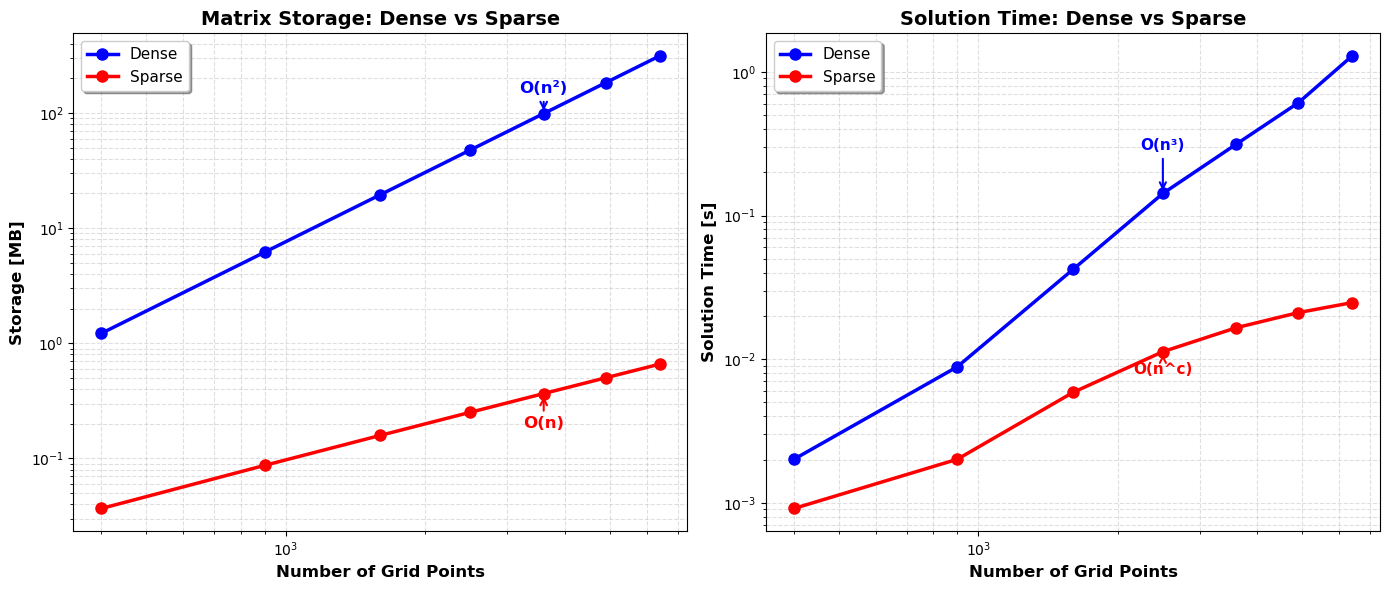

In [133]:
if __name__ == "__main__":
    # Generate the comparison plots
    create_comparison_plots()

# Stage 2 – Iterative Solvers (Dense Matrix, 30×30)

C:\Users\khali\AppData\Local\Temp\ipykernel_35548\3320648910.py:868: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.B[idx] = b_val


ITERATIVE SOLVERS COMPARISON - 30×30 GRID

Running Jacobi method...
Running Gauss-Seidel method...
Running SOR method (ω=1.5)...

RESULTS SUMMARY
Method          Iterations   Final Residual  Time (s)  
----------------------------------------------------------------------
Jacobi          2000         1.33e-02        0.3915    
Gauss-Seidel    1662         9.96e-04        9.3142    
SOR (ω=1.5)     557          9.91e-04        3.4876    


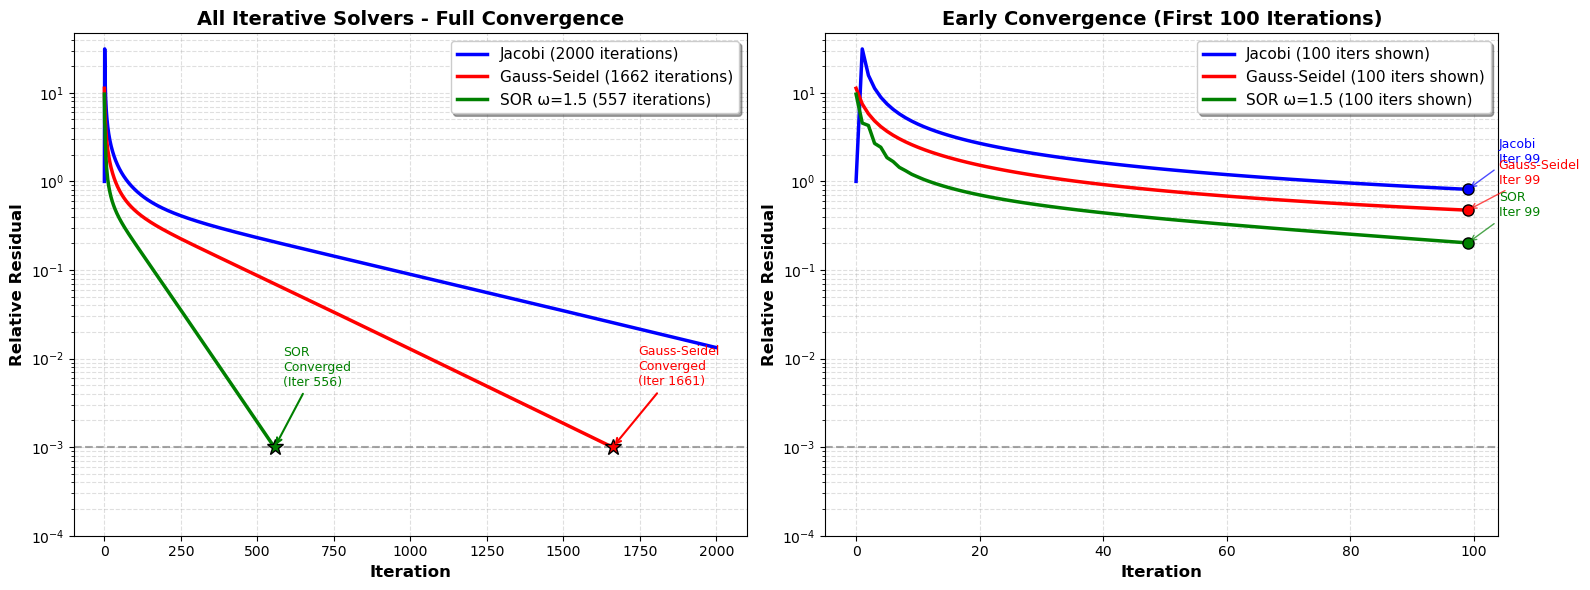

In [135]:
if __name__ == "__main__":
    # Run the iterative solvers comparison
    T_jacobi, T_gs, T_sor, res_jacobi, res_gs, res_sor = run_iterative_solvers_comparison()